# Mean Reversion

We test our cross-sectional mean reversion strategy on an unseen dataset spanning January 2025 to February 2026, using 4-hour crypto data across a universe of 70 assets. This section serves as a self-contained summary of the combined strategy and its out-of-sample performance.

### Strategy overview

The strategy uses both rolling PCA and OLS to decompose asset returns into a common market factor and an idiosyncratic residual component. By removing the dominant principal component and the market-proxy component, we isolate the idiosyncratic return of each asset and construct two separate signals, which are then averaged into a single combined signal. The strategy assumes this idiosyncratic component is mean reverting over short horizons: assets that have recently outperformed relative to the market factor are expected to give back those gains, and vice versa. We therefore go long assets with the most negative residuals and short those with the most positive, constructing a dollar-neutral portfolio with no net directional market exposure.

To make the strategy viable after transaction costs, we apply two smoothing mechanisms. First, residuals are smoothed using an exponential weighted moving average (EWM, alpha=0.5) before signal construction. Second, portfolio weights are partially adjusted at each rebalance, blending target weights with the previous period's weights at a rate of rho=0.95, which reduces turnover and extends the average holding period to approximately 5.2 days. Without these adjustments the strategy would be unprofitable at 20bps transaction costs due to excessive turnover.

### Parameter selection

Parameters were selected via a grid search on the in-sample training period (2022–2024), optimising for net Sharpe ratio. The optimal configuration uses 1 principal component, a 30-day rolling window, BTC as the OLS market proxy, rho=0.95, alpha=0.5, and a rank threshold of 0.05, meaning only the top and bottom 5% of assets by residual magnitude are assigned non-zero weights at each rebalance.

### Out-of-sample results

The strategy achieves a gross Sharpe ratio of 1.88 and a net Sharpe ratio of 0.78 on the unseen out-of-sample dataset, with an annualised return of 24.2% and annualised volatility of 12.9%. The annualised alpha is 24.6% with a t-statistic of 2.07, exceeding the 5% significance threshold and confirming that excess returns are statistically significant. Beta is near zero (0.02), confirming the strategy maintains its market-neutral character throughout. Transaction costs impose a meaningful drag of 14.1% annualised, reflecting the cost of the high rebalancing frequency inherent to a short-horizon mean reversion strategy.

These results are broadly consistent with in-sample performance, suggesting the strategy generalises reasonably well and the signal reflects genuine mean reversion rather than an artefact of parameter overfitting. That said, the reduction in net Sharpe from 1.31 in-sample to 0.78 out-of-sample warrants some caution.

The combined model compares favourably to the standalone OLS method, which produces a gross Sharpe of 1.57 and net Sharpe of 0.33 over the same period. The combined model's more modest performance relative to standalone PCA likely reflects its partial exposure to the OLS component, where ETH's decoupling from the broader altcoin universe in 2025 renders it a poor market proxy, contaminating the residuals.

In [1]:
cd -q ../../

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.backtest.backtest import run_backtest
from src.backtest.helpers import sharpe
from src.analysis.stats import rolling_sharpe, plot_drawdown

sns.set_theme(style="darkgrid", context="notebook", palette="deep")

## Data

In [3]:
start_ts = '2022-01-01'
end_ts = '2026-02-28'
freq = "4h"

In [4]:
px_parquet_path = f"src/data/px_{start_ts[:4]}_to_{end_ts[:4]}_{freq}.parquet"
rets_parquet_path = f"src/data/rets_{start_ts[:4]}_to_{end_ts[:4]}_{freq}.parquet"
rets = pd.read_parquet(rets_parquet_path)
px = pd.read_parquet(px_parquet_path)

In [5]:
px = px.loc["20240601":]

## Results of Out-of-sample Test

The out-of-sample results for the combined model are stronger than those of the standalone OLS strategy but weaker than PCA alone. The gross Sharpe ratio of 1.87 and net Sharpe ratio of 0.78 are somewhat below the in-sample figures of 2.39 and 1.32 respectively, though the degree of degradation is modest and consistent with reasonable out-of-sample generalisation.

The annualised alpha of 24.6% with a t-statistic of 2.07 exceeds the 5% significance threshold, confirming statistically significant excess returns. Beta of 0.02 and R-squared of 0.67% are both negligible, confirming the strategy remains effectively market-neutral with no meaningful exposure to BTC. The hit rate of 0.54 and average turnover of 0.032 are both stable relative to in-sample, suggesting signal quality and portfolio construction are consistent across periods.

By comparison, the standalone OLS strategy produces a net Sharpe of 0.33 with a statistically insignificant alpha (t-stat = 1.75) over the same period, while PCA alone achieves a net Sharpe of 1.10. The combined model sits between the two, partially inheriting the OLS component's weakness during a period in which ETH performs poorly as a market proxy.

In [6]:
oos = run_backtest(
    px,
    freq="4h", 
    rho=0.95, 
    rank_thresh=0.05, 
    alpha=0.5, 
    n_comp=1, 
    window_size=6*30, 
    mkt_ticker="BTCUSDT",
    method="combine",
    oos_start="2025-01-01"
    )

2026-03-08 19:25:15,247 INFO: Resampled to 4h


In [14]:
pd.DataFrame({x: y for x,y in oos.items() if type(y) is np.float64}, index=["oos"])

,avg_holding_days,gross_sharpe,net_sharpe,avg_ann,vol_ann,alpha_ann,alpha_tstat,beta,hit_rate,r_squared,avg_turnover,cost_drag_ann
oos,5.163768,1.876193,0.780836,0.241529,0.128734,0.246257,2.066099,0.023349,0.538795,0.006657,0.032206,0.141061


### Information Coefficient (IC) Analysis

The plot below shows the Information Coefficient (IC) at horizons of 1 through 24 bars, measured as the Spearman rank correlation between the residual signal at time t and forward returns at time t+h. At h=1 (4 hours) the mean IC is -0.06, confirming a meaningful mean reversion signal, which decays rapidly to -0.02 by h=2 and turns positive at longer horizons as momentum begins to dominate. This rapid decay motivates rebalancing every bar, and explains why aggressive smoothing via rho=0.95 and EWM alpha=0.5 is necessary; without these, the turnover required to act on the h=1 signal at every bar would be prohibitive at 20bps transaction costs

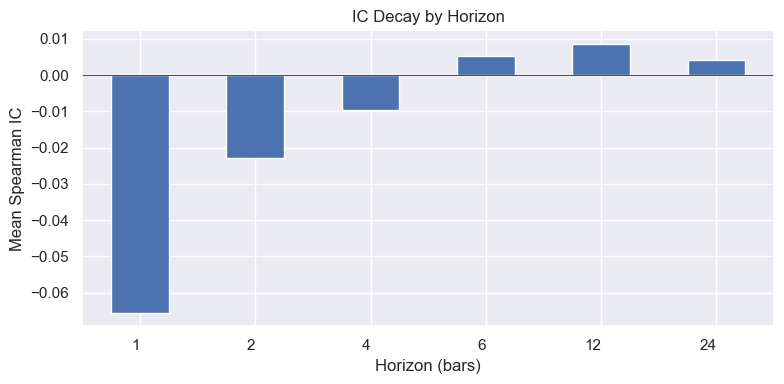

In [8]:
ic = oos["ic"]

pd.Series(ic).plot(kind="bar", figsize=(8, 4), title="IC Decay by Horizon")
plt.axhline(0, color="black", linewidth=0.5)
plt.xlabel("Horizon (bars)")
plt.ylabel("Mean Spearman IC")
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

### Rolling net sharpe ratio

The rolling net Sharpe ratio is generally positive and strong throughout the first half of the out-of-sample period. Performance degrades in late 2025, coinciding with broader crypto bear market conditions. Rolling Sharpe improves through the start of 2026.

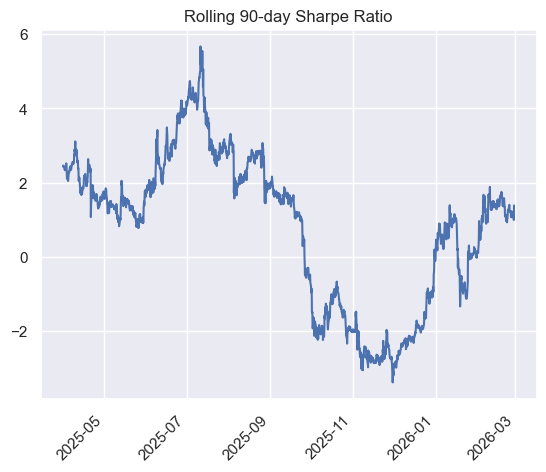

In [9]:
gross_ret = oos["gross_ret"]
net_ret = oos["net_ret"]

roll_sharpe = rolling_sharpe(net_ret)

### Cumulative returns

Out-of-sample cumulative returns outperform BTC buy-and-hold throughout the period, with the gap widening from late 2025 as bear market conditions take hold. The strategy's market-neutral construction insulates it from BTC's drawdowns, and its ability to generate positive returns during a down market offers genuine diversification value that a passive BTC position cannot.

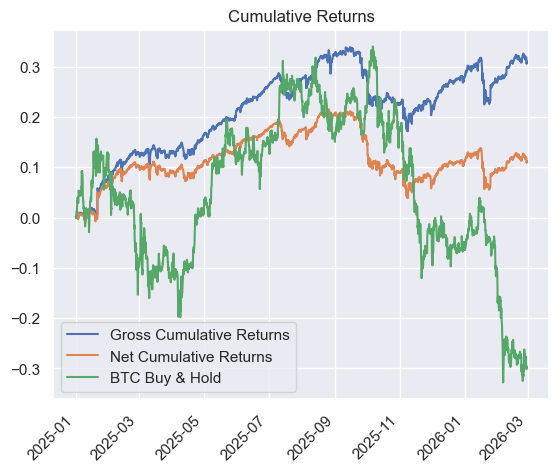

In [10]:
gross_cum = oos["gross_cum"]
net_cum = oos["net_cum"]

rets = rets.loc["20250101":]
btc_cum = (1 + rets["BTCUSDT"]).cumprod() - 1

plt.plot(gross_cum, label="Gross Cumulative Returns")
plt.plot(net_cum, label="Net Cumulative Returns")
plt.plot(btc_cum, label="BTC Buy & Hold")
plt.title("Cumulative Returns")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

### Drawdown

Our most notable drawdown period spans approximately 160 days from September 2025 through to March 2026, reaching a trough of -0.15. This coincides with the broader crypto bear market conditions identified in the cumulative returns analysis, where rising cross-sectional correlation compressed idiosyncratic return dispersion and weakened the mean reversion signal.

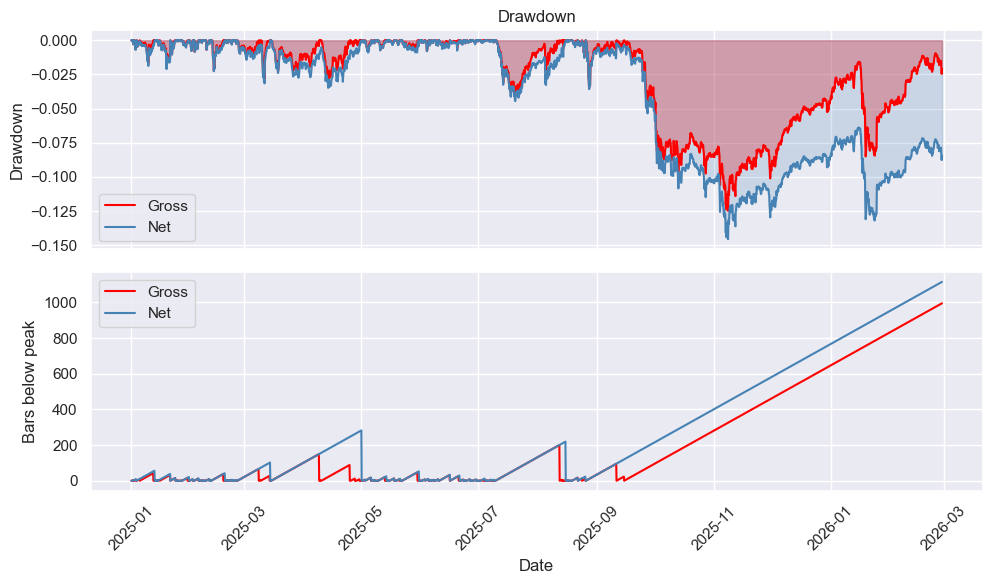

In [11]:
plot_drawdown(gross_ret, net_ret, title = "Drawdown")

### Cost analysis

Turnover remains stable throughout the out-of-sample period, averaging 0.032 per bar, identical to the in-sample value, as a result of the smoothing mechanisms put in place. The partial adjustment parameter (rho=0.95) and EWM residual smoothing (alpha=0.5) continue to effectively limit portfolio churn.

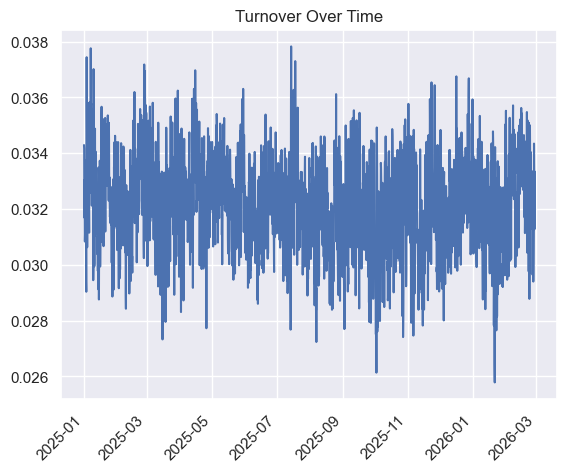

In [15]:
to = oos["to"]
STRAT_TIME  = 4
BARS_PER_DAY = 24 // STRAT_TIME
window_size = 15 * BARS_PER_DAY
ann_factor = 365 * BARS_PER_DAY

plt.plot(to)
plt.title("Turnover Over Time")
plt.xticks(rotation=45, ha='right')
plt.show()

In the following, we show that as transaction costs increase beyond our 20bps baseline assumption, strategy performance degrades materially. At 30bps the net Sharpe falls to 0.54, and at 40bps the strategy becomes unprofitable with a net Sharpe of -0.32, inconsistent with the in-sample test which achieved positive net Sharpe at 40 bps.

In [13]:
for bps in [15, 20, 30, 40]:
    net = gross_ret - to * bps * 1e-4
    print(f"{bps:3d}bps: net Sharpe = {sharpe(net, ann_factor):.2f}")

 15bps: net Sharpe = 1.05
 20bps: net Sharpe = 0.78
 30bps: net Sharpe = 0.23
 40bps: net Sharpe = -0.32
